Algoritmo Genético para gerar as dimensões de um núcleo de aço silício.

Esse algoritmo vai gerar uma lista de valores de larguras e espessuras para os degraus do núcleo de aço silíco de um transformador, os valores gerados já estarão discretizados, portanto, eles já poderão ser utilizados para construir um núcleo real. Esse algoritmo é útil para gerar núcleos de transformadores de pequeno e médio porte, entretanto, para núcleos de transformadores de alta potência, que na maioria das vezes irão precisar de canais de refrigeração entre os degraus, ele ainda não está pronto para lidar com esses casos, mas futuramente é uma modificação que poderia ser programada, permitindo que o algoritmo seja capaz de incluir esses canais de refrigeração.

O código foi desenvolvido por Henriqui Ferreira Segantini, como um trabalho na disciplina de Inteligência Artificial do Programa de Pós Graduação em Informática pela Universidade Tecnológica Federal do Paraná (UTFPR).

In [ ]:
import random
import math
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List
import multiprocessing

CONFIGURAÇÕES DO NÚCLEO

In [ ]:
# Representa o diâmetro da coluna do núcleo, o algoritmo irá respeitar esse limite e 
# não irá permitir que os vértices dos degraus ultrapassem essa fronteira.
DIAMETRO_NUCLEO = 300

# A quantidade de degraus em cada hemisfério, que o núcleo gerado irá possuir.
QTD_DEGRAUS = 8

# A espessura de 1 pacote de step lap, todas as espessuras geradas serão múltiplos desse valor.
ESPESSURA_STEP_LAP = 2.7

# O intervalo entre as larguras do núcleo, todas as larguras geradas serão múltiplos desse valor,
# para as larguras do núcleo, geralmente são utilizados valores inteiro múltiplos de 5, 10 ou 20, 
# mas o algoritmo também é capaz de lidar com valores decimais.
INTERVALO_ENTRE_LARGURAS = 10

# Fator de empilhamento utilizado para calcular a área da secção magnética.
FATOR_EMPILHAMENTO = 0.96

CONFIGURAÇÕES DO ALGORITMO

In [ ]:
TAMANHO_POPULACAO = 250

# Quantidade de gerações que o algoritmo irá gerar, quanto maior esse número, maior será o tempo de execução do algoritmo, usar valores múltiplos de 50.
GERACOES = 5000 

TAXA_MUTACAO = 0.5

CLASSES

In [ ]:
@dataclass
class Degrau:
    largura: float   # Em mm
    espessura: float # Em mm (deve ser sempre múltiplo do pacote de step lap, ex: 2.7mm)

@dataclass
class CromossomoNucleo:
    degraus: List[Degrau]
    fitness: float = 0.0

GERAR INDIVÍDUO

In [ ]:
def gerar_individuo_aleatorio(raio_maximo: float) -> CromossomoNucleo:
    """
    Gera um núcleo inicial com larguras decrescentes e espessuras baseadas no step lap.
    A lógica aqui deve garantir que o indivíduo nasça "quase" dentro do círculo para ajudar o algoritmo.
    """
    degraus = []
    y_acumulado = 0.0

    # Distribui a altura total disponível aleatoriamente entre os degraus
    altura_total_estimada = raio_maximo * random.uniform(0.75, 0.99)
    espessura_base = (altura_total_estimada / QTD_DEGRAUS)

    # Arredonda para o múltiplo mais próximo do step lap (ex: 2.7)
    espessura_base = round(espessura_base / ESPESSURA_STEP_LAP) * ESPESSURA_STEP_LAP

    for i in range(QTD_DEGRAUS):
        y_acumulado += espessura_base

        # Calcula a largura máxima teórica para esse Y usando Pitágoras (x^2 + y^2 = R^2)
        if y_acumulado < raio_maximo:
            largura_maxima = 2 * math.sqrt(raio_maximo**2 - y_acumulado**2)
        else:
            largura_maxima = 10.0 # Valor mínimo de escape

        # Adiciona uma pequena variação aleatória para o AG ter o que otimizar
        largura = largura_maxima * random.uniform(0.9, 1.0)

        # Discretiza a largura para ser um múltiplo de 10
        largura = round(largura / INTERVALO_ENTRE_LARGURAS) * INTERVALO_ENTRE_LARGURAS
        if largura < INTERVALO_ENTRE_LARGURAS: # Garante uma largura mínima de 10mm
            largura = INTERVALO_ENTRE_LARGURAS

        degraus.append(Degrau(largura=largura, espessura=espessura_base))

    cromossomo = CromossomoNucleo(degraus=degraus)
    normalizar_larguras(cromossomo) # Normaliza as larguras após a criação inicial
    return cromossomo

FITNESS FUNCTION

In [ ]:
def avaliar_fitness(cromossomo: CromossomoNucleo, raio_maximo: float) -> float:
    """
    Calcula a área útil do núcleo e aplica punições severas se bater na fronteira do círculo.
    """
    area_total = 0.0
    y_acumulado = 0.0
    penalidade = 0.0

    for degrau in cromossomo.degraus:
        # A área considera toda a chapa (Largura x Espessura)
        area_total += degrau.largura * degrau.espessura

        # Coordenadas do canto superior direito do degrau (x, y)
        x_canto = degrau.largura / 2.0
        y_acumulado += degrau.espessura
        y_canto = y_acumulado

        # Verifica a distância do canto até o centro do círculo
        distancia_centro = math.sqrt(x_canto**2 + y_canto**2)

        # Se a distância for maior que o raio, o degrau rasgou a fronteira
        if distancia_centro > raio_maximo:
            # Penalidade progressiva: quanto mais para fora, pior a nota
            excesso = distancia_centro - raio_maximo
            penalidade += (excesso * 5000) # Peso multiplicador ajustável

    # Área magnética real = (Soma da área de metade da coluna * 2) * Fator de Empilhamento
    area_magnetica = (area_total * 2) * FATOR_EMPILHAMENTO

    # O fitness final é a área menos os erros geométricos
    cromossomo.fitness = area_magnetica - penalidade
    return cromossomo.fitness

ALGORITMO GENÉTICO


In [ ]:
def selecao_torneio(populacao: List[CromossomoNucleo], tamanho_torneio: int = 3) -> CromossomoNucleo:
    """
    Pega N indivíduos aleatórios da população e retorna o que tiver a maior nota (fitness).
    """
    competidores = random.sample(populacao, tamanho_torneio)
    competidores_ordenados = sorted(competidores, key=lambda c: c.fitness, reverse=True)
    return competidores_ordenados[0]


def cruzamento_um_ponto(pai1: CromossomoNucleo, pai2: CromossomoNucleo) -> CromossomoNucleo:

    # Pega metade dos degraus do Pai 1 (ex: miolo do núcleo) e junta com a metade do Pai 2 (bordas).
    # OBS: Sempre vai cortar na metade, portanto, não varia tanto
    # ponto_corte = len(pai1.degraus) // 2

    # Define um ponto de corte aleatório, para incluir mais variação
    ponto_corte = random.randint(1, len(pai1.degraus) - 1)

    # Copia os degraus para evitar referências de memória indesejadas
    filho_degraus = [Degrau(d.largura, d.espessura) for d in pai1.degraus[:ponto_corte]]
    filho_degraus += [Degrau(d.largura, d.espessura) for d in pai2.degraus[ponto_corte:]]

    return CromossomoNucleo(degraus=filho_degraus)


def mutacao(cromossomo: CromossomoNucleo):
    """
    Percorre os degraus e aplica pequenas alterações de largura ou espessura.
    """
    for degrau in cromossomo.degraus:
        if random.random() < TAXA_MUTACAO:
            # Escolhe aleatoriamente se vai mutar a largura ou a espessura
            if random.random() < 0.5:
                # Muta a largura em até +/- 5%
                degrau.largura *= random.uniform(0.95, 1.05)
                # Discretiza a largura para ser um múltiplo de 10
                degrau.largura = round(degrau.largura / 10) * 10
                if degrau.largura < 10.0: # Garante uma largura mínima de 10mm
                    degrau.largura = 10.0
            else:
                # Adiciona ou remove um pacote de step laps
                variacao = random.choice([-1, 1]) * ESPESSURA_STEP_LAP
                degrau.espessura += variacao
                if degrau.espessura < ESPESSURA_STEP_LAP:
                    degrau.espessura = ESPESSURA_STEP_LAP # Evita espessura zero ou negativa

def normalizar_larguras(cromossomo: CromossomoNucleo):
    """
    Garante que as larguras dos degraus sejam estritamente decrescentes e múltiplos de INTERVALO_ENTRE_LARGURAS.
    """
    # Garante que a largura do primeiro degrau seja um múltiplo e não muito pequena
    cromossomo.degraus[0].largura = max(INTERVALO_ENTRE_LARGURAS, round(cromossomo.degraus[0].largura / INTERVALO_ENTRE_LARGURAS) * INTERVALO_ENTRE_LARGURAS)

    for i in range(1, len(cromossomo.degraus)):
        degrau_atual = cromossomo.degraus[i]
        degrau_anterior = cromossomo.degraus[i-1]

        # Primeiro, garante que é um múltiplo de INTERVALO_ENTRE_LARGURAS e não abaixo do mínimo
        degrau_atual.largura = max(INTERVALO_ENTRE_LARGURAS, round(degrau_atual.largura / INTERVALO_ENTRE_LARGURAS) * INTERVALO_ENTRE_LARGURAS)

        # Impõe a restrição de decréscimo estrito
        # Se a largura atual não for estritamente menor que a anterior, ajusta
        while degrau_atual.largura >= degrau_anterior.largura:
            degrau_atual.largura -= INTERVALO_ENTRE_LARGURAS
            # Garante que não vá abaixo da largura mínima permitida
            if degrau_atual.largura < INTERVALO_ENTRE_LARGURAS:
                degrau_atual.largura = INTERVALO_ENTRE_LARGURAS
                break # Não pode diminuir mais, então pare

FUNÇÃO PRINCIPAL

In [ ]:
def otimizar_projeto_nucleo():
    # 1. Configurações Iniciais
    RAIO = DIAMETRO_NUCLEO / 2.0

    # Listas para monitoramento do progresso
    historico_melhor_fitness = []
    historico_fitness_medio = []

    # 2. Inicializar População
    populacao = [
        gerar_individuo_aleatorio(RAIO)
        for _ in range(TAMANHO_POPULACAO)
    ]

    melhor_solucao_global = None

    # Usar um pool de processos para paralelizar a avaliação de fitness
    # O número de processos pode ser ajustado para otimizar o uso da CPU
    num_cores = multiprocessing.cpu_count()
    pool = multiprocessing.Pool(processes=num_cores)

    # 3. Loop Evolutivo
    for geracao in range(GERACOES):

        # Passo A: Avaliar toda a população em paralelo
        # Criar uma lista de argumentos para starmap: [(individuo1, RAIO), (individuo2, RAIO), ...]
        args_para_fitness = [(individuo, RAIO) for individuo in populacao]

        # starmap aplica avaliar_fitness a cada tupla de argumentos e retorna os fitness values
        fitness_scores = pool.starmap(avaliar_fitness, args_para_fitness)

        # Atribuir os scores de volta aos cromossomos e identificar o melhor
        for i, individuo in enumerate(populacao):
            individuo.fitness = fitness_scores[i]
            # Rastrea o melhor de todos os tempos
            if melhor_solucao_global is None or individuo.fitness > melhor_solucao_global.fitness:
                # Importante fazer uma cópia profunda (deep copy) do melhor
                melhor_solucao_global = CromossomoNucleo(
                    degraus=[Degrau(d.largura, d.espessura) for d in individuo.degraus],
                    fitness=individuo.fitness
                )
                normalizar_larguras(melhor_solucao_global) # Normaliza a melhor solução encontrada

        # Registro para o gráfico de monitoramento
        melhor_da_geracao = max(fitness_scores)
        media_da_geracao = sum(fitness_scores) / len(fitness_scores)
        historico_melhor_fitness.append(melhor_da_geracao)
        historico_fitness_medio.append(media_da_geracao)

        nova_populacao = []

        # Elitismo: Passar o melhor indivíduo direto para a próxima geração
        nova_populacao.append(melhor_solucao_global)

        # Passo B: Criar a nova geração
        while len(nova_populacao) < TAMANHO_POPULACAO:
            # Seleciona dois pais competentes
            pai1 = selecao_torneio(populacao)
            pai2 = selecao_torneio(populacao)

            # Reproduz e cria um filho
            filho = cruzamento_um_ponto(pai1, pai2)

            # Sofre mutação
            mutacao(filho)

            normalizar_larguras(filho) # Normaliza as larguras do filho após cruzamento e mutação

            # Adiciona à nova geração
            nova_populacao.append(filho)

        # Atualiza a população para o próximo ciclo
        populacao = nova_populacao

        # (Opcional) Log de progresso a cada 50 gerações
        if geracao % 50 == 0:
            print(f"Geração {geracao} | Melhor Fitness (Área Útil): {melhor_solucao_global.fitness:.2f} mm²")

    # Fechar o pool de processos
    pool.close()
    pool.join()

    # 4. Geração do Gráfico de Evolução
    plt.figure(figsize=(10, 5))
    plt.plot(historico_melhor_fitness, label='Melhor Fitness', color='green')
    plt.plot(historico_fitness_medio, label='Fitness Médio', color='blue', linestyle='--')
    plt.title("Evolução do Algoritmo Genético")
    plt.xlabel("Geração")
    plt.ylabel("Fitness (Área Útil mm²)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # 5. Retorno do Resultado
    print("\nRESULTADOS:")

    # Cálculos de indicadores de eficiência
    area_circulo = math.pi * (RAIO**2)
    # Área geométrica total (soma das áreas de cada degrau * 2 para cobrir os dois lados)
    area_geometrica_total = sum(d.largura * d.espessura for d in melhor_solucao_global.degraus) * 2
    area_magnetica_total = area_geometrica_total * FATOR_EMPILHAMENTO

    porcentagem_ocupada = (area_geometrica_total / area_circulo) * 100
    porcentagem_magnetica = (area_magnetica_total / area_circulo) * 100

    print(f"Diâmetro do núcleo: {DIAMETRO_NUCLEO} mm")
    print(f"Fator de empilhamento: {FATOR_EMPILHAMENTO * 100:.1f} %")
    print(f"\nÁrea da Circunferência: {area_circulo:.2f} mm²")
    print(f"Área da Secção Coluna (Geométrica): {area_geometrica_total:.2f} mm²")
    print(f"Área da Secção Magnética: {area_magnetica_total:.2f} mm²")
    print(f"\nPorcentagem da área ocupada: {porcentagem_ocupada:.2f} %")
    print(f"Porcentagem da secção magnética: {porcentagem_magnetica:.2f} %")

    return melhor_solucao_global

FUNÇÃO PARA DESENHAR O RESULTADO

In [ ]:
def plotar_nucleo(melhor_solucao: CromossomoNucleo, diametro: float):
    raio = diametro / 2.0
    fig, ax = plt.subplots(figsize=(8, 8))

    # Desenha o círculo do núcleo
    circulo = plt.Circle((0, 0), raio, color='lightgray', fill=False, linestyle='--', label='Fronteira do Núcleo')
    ax.add_patch(circulo)

    y_atual = 0
    # Desenha cada degrau (espelhado nos 4 quadrantes)
    for degrau in melhor_solucao.degraus:
        largura = degrau.largura
        espessura = degrau.espessura

        # Retângulo centralizado em X, subindo em Y
        # Rect: (x_inferior_esquerdo, y_inferior_esquerdo), largura, altura
        rect_sup = plt.Rectangle((-largura/2, y_atual), largura, espessura,
                                 edgecolor='navy', facecolor='royalblue', alpha=0.7)
        rect_inf = plt.Rectangle((-largura/2, -y_atual - espessura), largura, espessura,
                                 edgecolor='navy', facecolor='royalblue', alpha=0.7)

        ax.add_patch(rect_sup)
        ax.add_patch(rect_inf)
        y_atual += espessura

    ax.set_xlim(-raio * 1.1, raio * 1.1)
    ax.set_ylim(-raio * 1.1, raio * 1.1)
    ax.set_aspect('equal')
    plt.title(f"Perfil do Núcleo Otimizado (Ø {diametro}mm)")
    plt.xlabel("Largura (mm)")
    plt.ylabel("Espessura (mm)")
    plt.grid(True, which='both', linestyle=':', alpha=0.5)
    plt.legend()
    plt.show()

EXECUTANDO O CÓDIGO

Quantidade de CPUs disponíveis: 2

Geração 0 | Melhor Fitness (Área Útil): 59097.60 mm²
Geração 50 | Melhor Fitness (Área Útil): 60756.48 mm²
Geração 100 | Melhor Fitness (Área Útil): 62259.84 mm²
Geração 150 | Melhor Fitness (Área Útil): 62259.84 mm²
Geração 200 | Melhor Fitness (Área Útil): 62259.84 mm²
Geração 250 | Melhor Fitness (Área Útil): 62259.84 mm²
Geração 300 | Melhor Fitness (Área Útil): 62622.72 mm²
Geração 350 | Melhor Fitness (Área Útil): 62622.72 mm²
Geração 400 | Melhor Fitness (Área Útil): 62622.72 mm²
Geração 450 | Melhor Fitness (Área Útil): 62622.72 mm²
Geração 500 | Melhor Fitness (Área Útil): 62622.72 mm²
Geração 550 | Melhor Fitness (Área Útil): 62622.72 mm²
Geração 600 | Melhor Fitness (Área Útil): 62622.72 mm²
Geração 650 | Melhor Fitness (Área Útil): 62622.72 mm²
Geração 700 | Melhor Fitness (Área Útil): 62622.72 mm²
Geração 750 | Melhor Fitness (Área Útil): 62674.56 mm²
Geração 800 | Melhor Fitness (Área Útil): 62674.56 mm²
Geração 850 | Melhor Fitness (Áre

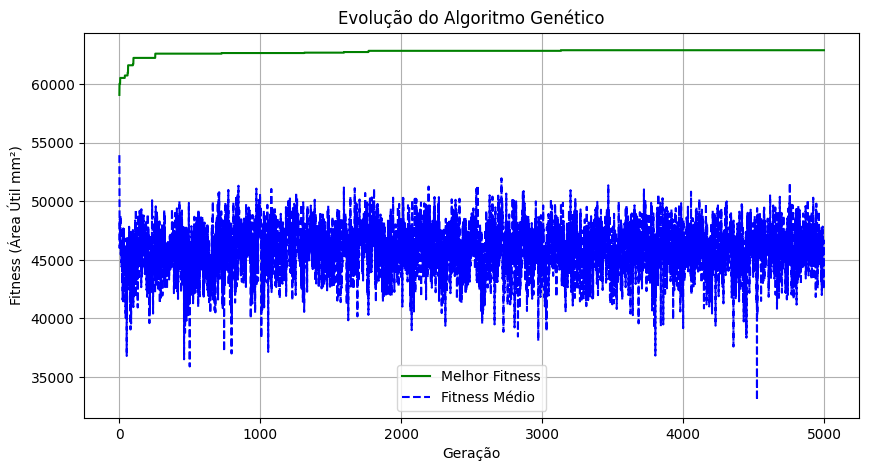


RESULTADOS:
Diâmetro do núcleo: 300 mm
Fator de empilhamento: 96.0 %

Área da Circunferência: 70685.83 mm²
Área da Secção Coluna (Geométrica): 65610.00 mm²
Área da Secção Magnética: 62985.60 mm²

Porcentagem da área ocupada: 92.82 %
Porcentagem da secção magnética: 89.11 %

Especificações do Melhor Núcleo:


,Degrau,Largura (mm),Espessura (mm)
0,1,290,37.8
1,2,280,13.5
2,3,260,21.6
3,4,240,16.2
4,5,220,10.8
5,6,190,16.2
6,7,150,13.5
7,8,100,10.8


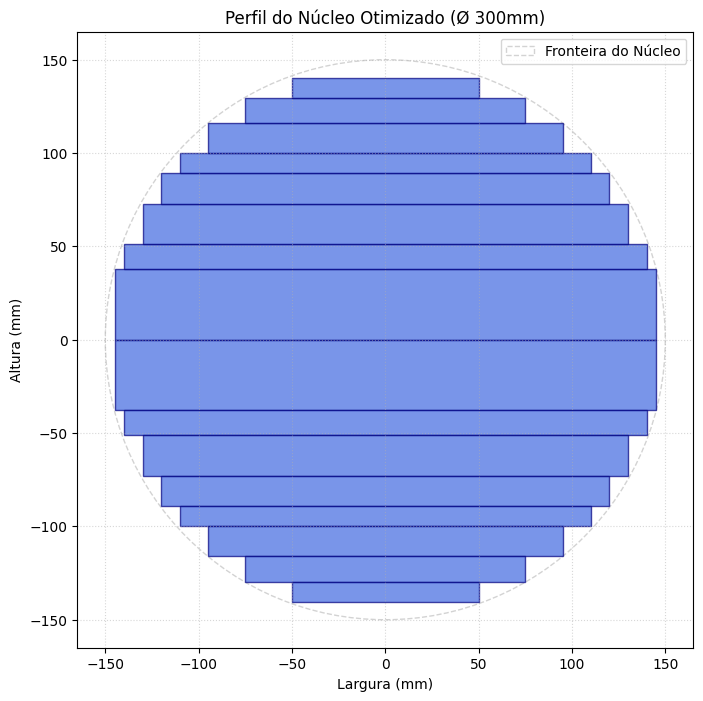

In [ ]:
import pandas as pd

# Ponto de entrada do script
if __name__ == "__main__":
    num_cpus = multiprocessing.cpu_count()
    print(f"Quantidade de CPUs disponíveis: {num_cpus}\n")

    melhor_nucleo = otimizar_projeto_nucleo()

    # Preparar dados para a tabela
    dados_degraus = []
    for i, degrau in enumerate(melhor_nucleo.degraus):
        dados_degraus.append({"Degrau": i + 1, "Largura (mm)": degrau.largura, "Espessura (mm)": degrau.espessura})

    # Criar DataFrame e exibir
    df_degraus = pd.DataFrame(dados_degraus)
    print("\nEspecificações do Melhor Núcleo:")
    display(df_degraus)

    # Visualizar o núcleo otimizado
    plotar_nucleo(melhor_nucleo, DIAMETRO_NUCLEO)